# Анализ качества атмосферного воздуха в мировом масштабе

**Автор:** tamagotchi_fibi 
**Дата:** апрель 2026

**Описание:** данные взяты с сайта Kaggle, автор - Hasib al Muzdadid. Записей - 23463, столбцов - 12. Признаки: Country, City, AQI Value, AQI Category, CO AQI Value, CO AQI Category, Ozone AQI Value, Ozone AQI Category, NO2 AQI Value, NO2 AQI Category, PM2.5 AQI Value, PM2.5 AQI Category.

**Загрязнители, представленные в датасете:**
- **CO** (угарный газ) - образуется при неполном сгорании топлива: выхлопы транспорта, промышленные выбросы;
- **Ozone** (приземный озон) - образуется при взаимодействии солнечного излучения с выбросами транспорта и промышленности;
- **NO2** (диоксид азота) - выбросы транспорта и тепловых электростанций;
- **PM2.5** (мелкодисперсные частицы) - наиболее опасный загрязнитель, проникает в лёгкие и кровоток. Источники: сжигание топлива, промышленность, пыль.

**Цель проекта** - выявить наиболее неблагоприятные для здоровья человека регионы мира на основе анализа качества атмосферного воздуха.

Анализ предназначен для специалистов в области экологии и природопользования и позволяет оценить степень загрязнённости атмосферы по ключевым показателям в различных точках Земли. Проект основан на данных о качестве воздуха за 2023 год.

**Структура:**
1. Загрузка данных
2. Первичный осмотр данных
3. Очистка данных и заполнение пропусков
4. Анализ данных
   - Общее распределение записей по категориям AQI
   - Топ-10 наиболее загрязнённых стран
      - Общий рейтинг
      - Рейтинг репрезентативных стран
   - Топ-5 наиболее загрязнённых городов
   - Определение основных загрязнителей в топ-5 городах
5. Выводы

**Ссылка на датасет:** https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset

## 1. Загрузка данных

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('air_pollution.csv')
data_copy = data.copy()
conn = sqlite3.connect(':memory:')

Датасет загружен успешно.

## 2. Первичный осмотр данных

Первые 5 строк датасета:

In [2]:
data.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


In [3]:
display(data.shape)
data.info()
data.isnull().sum()

(23463, 12)

<class 'pandas.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Country             23036 non-null  str  
 1   City                23462 non-null  str  
 2   AQI Value           23463 non-null  int64
 3   AQI Category        23463 non-null  str  
 4   CO AQI Value        23463 non-null  int64
 5   CO AQI Category     23463 non-null  str  
 6   Ozone AQI Value     23463 non-null  int64
 7   Ozone AQI Category  23463 non-null  str  
 8   NO2 AQI Value       23463 non-null  int64
 9   NO2 AQI Category    23463 non-null  str  
 10  PM2.5 AQI Value     23463 non-null  int64
 11  PM2.5 AQI Category  23463 non-null  str  
dtypes: int64(5), str(7)
memory usage: 2.1 MB


Country               427
City                    1
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
dtype: int64

In [4]:
data.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


23463 записей, 12 столбцов.
Первичный анализ статистики показывает следующее:

- **AQI Value:** медианное значение составляет 55, что соответствует категории "Moderate". Это означает, что более половины записей в датасете имеют уровень загрязнения выше "Good". Среднее значение (72) заметно выше медианы, а максимум достигает 500 - верхней границы шкалы. Это свидетельствует о наличии значительных выбросов.

- **PM2.5 AQI Value:** среднее значение (68) сопоставимо с общим AQI, а максимум также достигает 500. Это указывает на то, что PM2.5 является доминирующим загрязнителем в наиболее загрязнённых точках.

- **CO AQI Value:** среднее значение крайне низкое (1.37), однако максимум достигает 133. Стандартное отклонение превышает среднее, что говорит о сильном разбросе: в большинстве городов CO минимален, но в отдельных точках наблюдаются значительные выбросы.

- **Пропуски** обнаружены только в столбцах Country (427) и City (1) - менее 2% от общего объёма данных.

## 3. Очистка данных и заполнение пропусков

In [5]:
data = data.dropna(subset = ['Country', 'City'])
print(data.isnull().sum())
data.shape

Country               0
City                  0
AQI Value             0
AQI Category          0
CO AQI Value          0
CO AQI Category       0
Ozone AQI Value       0
Ozone AQI Category    0
NO2 AQI Value         0
NO2 AQI Category      0
PM2.5 AQI Value       0
PM2.5 AQI Category    0
dtype: int64


(23035, 12)

Удалено 428 строк с пропусками.

In [6]:
data.duplicated().sum()

np.int64(0)

Дубликатов нет.

In [7]:
data.to_sql('air_pollution', conn, index = False)

pd.read_sql("SELECT * FROM air_pollution LIMIT 5", conn)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


Очищенные данные записаны в базу SQLite для дальнейшего использования в SQL-запросах.

In [8]:
data.shape

(23035, 12)

Обновлённые очищенные данные: 23035 строк, 12 столбцов

## 4. Анализ данных
### 4.1. Общее распределение записей по категориям AQI

In [9]:
data['AQI Category'].unique()

<StringArray>
[                      'Moderate',                           'Good',
 'Unhealthy for Sensitive Groups',                      'Unhealthy',
                 'Very Unhealthy',                      'Hazardous']
Length: 6, dtype: str

В датасете присутствуют все 6 стандартных категорий AQI. 
Категории уже размечены, дополнительная группировка не требуется.

Способ 1: SQL

In [10]:
pd.read_sql("SELECT [AQI Category], COUNT(City) FROM air_pollution GROUP BY [AQI Category]", conn)

,AQI Category,COUNT(City)
0,Good,9688
1,Hazardous,191
2,Moderate,9087
3,Unhealthy,2215
4,Unhealthy for Sensitive Groups,1568
5,Very Unhealthy,286


Способ 2: Pandas

In [11]:
aqi_counts = data.groupby(['AQI Category'])['City'].count()
aqi_counts

AQI Category
Good                              9688
Hazardous                          191
Moderate                          9087
Unhealthy                         2215
Unhealthy for Sensitive Groups    1568
Very Unhealthy                     286
Name: City, dtype: int64

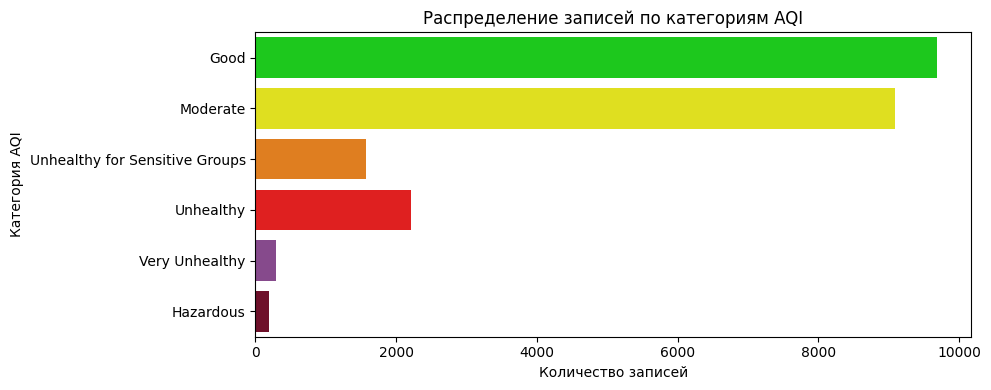

In [12]:
order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']

colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

aqi_counts = aqi_counts.reindex(order)

plt.figure(figsize=(10, 4))
sns.barplot(x=aqi_counts.values, y=aqi_counts.index, hue=aqi_counts.index, palette=colors, legend=False)
plt.title('Распределение записей по категориям AQI')
plt.xlabel('Количество записей')
plt.ylabel('Категория AQI')
plt.tight_layout()
plt.show()

Большинство записей в датасете (19 166 из 23 035) относятся к категориям "Good" и "Moderate", что говорит об относительно невысоком уровне загрязнения в большинстве точек мира на 2023 год. Тем не менее, 191 запись (0.83%) попадает в категорию "Hazardous" - это экстремальные значения, на которых сосредоточен основной интерес данного исследования. Дальнейший анализ покажет, какие загрязнители преобладают в наиболее опасных точках.

### 4.2. Топ-10 наиболее загрязнённых стран
#### 4.2.1. Общий рейтинг

In [13]:
pd.read_sql("SELECT Country, AVG([AQI Value]) AS AVG_AQI FROM air_pollution GROUP BY Country ORDER BY AVG([AQI Value]) DESC", conn)

,Country,AVG_AQI
0,Republic of Korea,421.000000
1,Bahrain,188.000000
2,Mauritania,179.000000
3,Pakistan,178.788274
4,United Arab Emirates,163.666667
...,...,...
170,Bolivia (Plurinational State of),23.787879
171,Iceland,23.000000
172,Maldives,19.000000
173,Solomon Islands,18.000000


AQI в Южной Корее в разы превышает AQI остальных стран. Необходима проверка:

In [14]:
data[data['Country'] == 'Republic of Korea']

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
1402,Republic of Korea,Seoul,421,Hazardous,27,Good,0,Good,91,Moderate,415,Hazardous


Результаты по Republic of Korea могут быть некорректны, так как датасет содержит недостаточное количество записей по данной стране (1 запись). Среднее значение по странам с малым количеством записей не является репрезентативным. Проверим остальные страны с малой выборкой:

In [15]:
quantity_cdata = data.groupby(['Country'])['City'].count()
small_sample_countries = quantity_cdata[quantity_cdata < 10]
print(f'Количество нерепрезентативных данных: {small_sample_countries.count()}')
small_sample_countries

Количество нерепрезентативных данных: 42


Country
Andorra                             3
Aruba                               1
Bahrain                             1
Barbados                            1
Belize                              3
Bhutan                              2
Cabo Verde                          2
Comoros                             3
Cyprus                              6
Equatorial Guinea                   4
Eritrea                             5
Gambia                              9
Guinea-Bissau                       4
Guyana                              4
Iceland                             3
Jamaica                             6
Kingdom of Eswatini                 3
Kuwait                              3
Lao People's Democratic Republic    8
Lebanon                             6
Lesotho                             5
Liberia                             9
Luxembourg                          2
Maldives                            1
Mauritania                          4
Monaco                              1
Mont

Среднее количество записей на страну - 131. Страны с менее чем 10 записями считаются статистически ненадёжными для анализа среднего AQI, так как это менее 8% от среднего по выборке. Стран с нерепрезентативной выборкой городов: 42. Данные страны включены в анализ, однако их результаты следует интерпретировать с осторожностью ввиду малого количества наблюдений.

Для расчёта среднего AQI по странам используется медиана, а не среднее арифметическое, так как в данных присутствуют выбросы (max AQI = 500 при среднем 72). Медиана устойчива к выбросам и даёт более корректную оценку.

In [16]:
top_10_countries = data.groupby(['Country'])['AQI Value'].median().nlargest(11)
top_10_countries = top_10_countries.drop('Republic of Korea')
top_10_countries

Country
Bahrain                 188.0
Pakistan                169.0
United Arab Emirates    169.0
Mauritania              167.5
Saudi Arabia            167.5
Aruba                   163.0
Kuwait                  161.0
Qatar                   157.5
Senegal                 157.0
Oman                    154.0
Name: AQI Value, dtype: float64

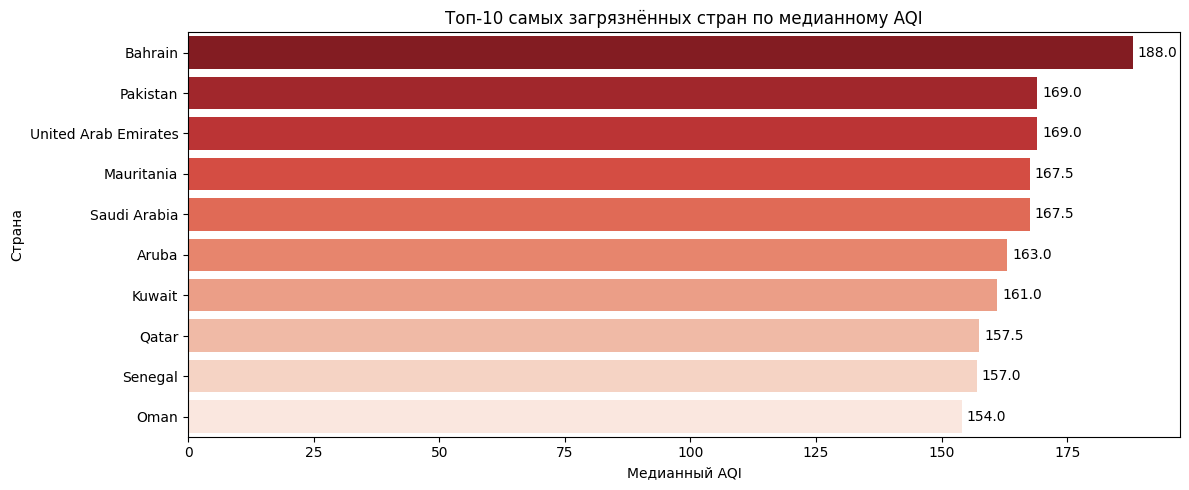

In [17]:
plt.figure(figsize=(12, 5))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index,
            hue=top_10_countries.index, palette='Reds_r', legend=False)
plt.title('Топ-10 самых загрязнённых стран по медианному AQI')
plt.xlabel('Медианный AQI')
plt.ylabel('Страна')
for i, v in enumerate(top_10_countries.values):
    plt.text(v + 1, i, str(round(v, 1)), va='center')
plt.tight_layout()
plt.show()

График показывает, что топ-10 наиболее загрязнённых стран имеют медианный AQI в диапазоне от 154 до 188, что соответствует категории Unhealthy - четвёртой из шести по шкале загрязнённости.

Примечательна географическая закономерность: большинство стран относятся к региону Ближнего Востока (Бахрейн, ОАЭ, Саудовская Аравия, Кувейт, Катар, Оман) и Западной Африки (Мавритания, Сенегал). Это может объясняться тем, что главной отраслью экономики стран Персидского залива исторически остаётся нефтегазовый сектор, обеспечивающий до 50% ВВП. Интенсивная добыча и переработка углеводородов является одним из ключевых факторов загрязнения атмосферного воздуха в данном регионе. Предположительно, дополнительными факторами являются пыльные бури, быстрое строительство, выбросы транспорта и промышленности, а также жаркий сухой климат, препятствующий естественному рассеиванию загрязнителей. Данная гипотеза требует дополнительного исследования с привлечением данных о промышленных выбросах и метеорологических показателях.

#### 4.2.2. Рейтинг репрезентативных стран

In [18]:
all_countries = data.groupby(['Country'])['AQI Value'].median()
reliable_countries = all_countries[~all_countries.index.isin(small_sample_countries.index)]
reliable_top10 = reliable_countries.nlargest(10)
reliable_top10

Country
Pakistan        169.0
Saudi Arabia    167.5
Senegal         157.0
India           153.0
China           137.0
Iraq            123.5
Nepal           120.0
Tajikistan      120.0
Uzbekistan      119.5
Turkmenistan    110.0
Name: AQI Value, dtype: float64

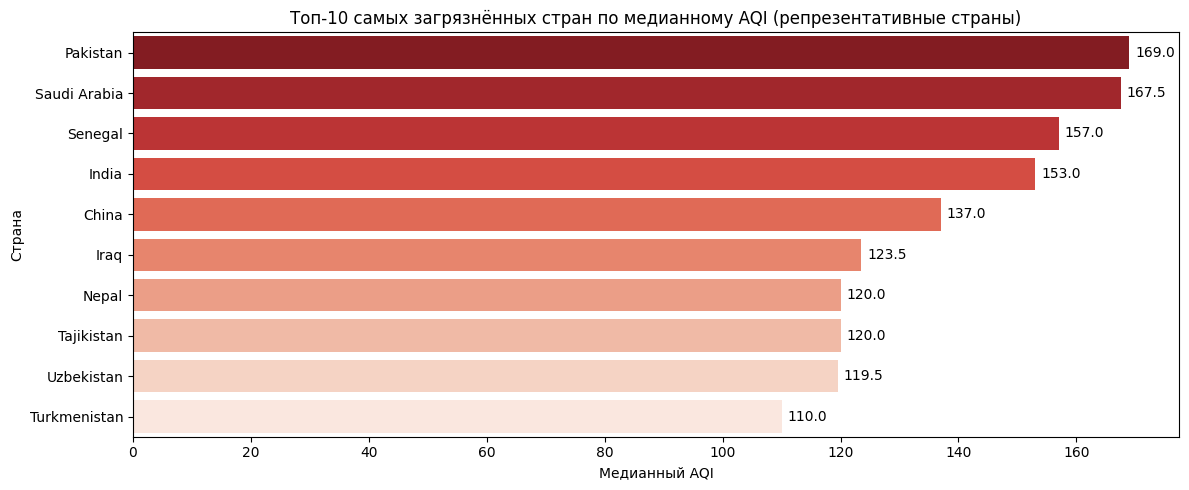

In [19]:
plt.figure(figsize=(12,5))
sns.barplot(x=reliable_top10.values, y=reliable_top10.index,
            hue=reliable_top10.index, palette='Reds_r', legend=False)
plt.title('Топ-10 самых загрязнённых стран по медианному AQI (репрезентативные страны)')
plt.xlabel('Медианный AQI')
plt.ylabel('Страна')
for i, v in enumerate(reliable_top10.values):
    plt.text(v + 1, i, str(round(v, 1)), va='center')
plt.tight_layout()
plt.show()

После исключения стран с нерепрезентативной выборкой (менее 10 записей) картина изменилась. В обновлённом топ-10 преобладают страны Южной и Центральной Азии: Пакистан, Индия, Непал, Таджикистан, Узбекистан, Туркменистан, Ирак. Саудовская Аравия и Сенегал сохранили позиции из предыдущего рейтинга.
Медианный AQI в репрезентативном топ-10 находится в диапазоне 110–169, что соответствует категории Unhealthy for Sensitive Groups и Unhealthy. Это ниже, чем в нерепрезентативном рейтинге, что подтверждает влияние малой выборки на результаты предыдущего графика.

### 4.3. Топ-5 наиболее загрязнённых городов

In [20]:
top_cities = data.nlargest(5, 'AQI Value')[['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]
top_cities

,Country,City,AQI Value,AQI Category,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
276,Pakistan,Bahawalnagar,500,Hazardous,1,38,1,466
470,India,Rania,500,Hazardous,1,40,0,464
524,India,Gohana,500,Hazardous,1,47,1,500
611,India,Gunnaur,500,Hazardous,1,73,1,500
620,Pakistan,Harunabad,500,Hazardous,1,43,0,443


Топ-5 наиболее загрязнённых городов мира имеют максимальное значение AQI = 500 - верхнюю границу шкалы, соответствующую категории Hazardous. Реальный уровень загрязнения в этих городах может превышать измеримые значения шкалы.
3 города из 5 относятся к Индии, 2 - к Пакистану. Это согласуется с репрезентативным рейтингом стран, где Пакистан занял 1 место, а Индия - 4. Таким образом, обе страны стабильно демонстрируют высокий уровень загрязнения как на уровне отдельных городов, так и на уровне страны в целом.
Для понимания причин экстремального загрязнения в топ-5 городах рассмотрим основные загрязнители. Все города расположены в Пакистане и Индии - регионах с высокой промышленной активностью.
Предположительно, основными источниками загрязнения в пакистанских городах являются промышленные выбросы, выхлопные газы транспорта, сжигание сельскохозяйственных отходов и кирпичные заводы. Вероятно, ключевым загрязнителем является PM2.5 - мелкодисперсные частицы, наиболее опасные для здоровья. Проверим это на данных.

### 4.4. Определение основных загрязнителей в топ-5 городах

In [21]:
top_cities[['Country', 'City', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']]

,Country,City,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
276,Pakistan,Bahawalnagar,1,38,1,466
470,India,Rania,1,40,0,464
524,India,Gohana,1,47,1,500
611,India,Gunnaur,1,73,1,500
620,Pakistan,Harunabad,1,43,0,443


Во всех топ-5 городах доминирующим загрязнителем является PM2.5 со значениями AQI от 443 до 500 - максимум шкалы. PM2.5 - мельчайшие частицы диаметром менее 2.5 мкм, которые проникают в лёгкие и кровоток. По данным ВОЗ (Всемирная организация здравоохранения), PM2.5 ежегодно вызывает около 7 миллионов преждевременных смертей в мире. CO, NO2 и озон в данных городах находятся на минимальном уровне, что подтверждает гипотезу о доминировании частиц PM2.5 как основного загрязнителя.

## 5. Выводы

Большинство записей в датасете (19 166 из 23 035) относятся к категориям "Good" и "Moderate", что свидетельствует об относительно невысоком уровне загрязнения в большинстве точек мира. Тем не менее 191 запись (0.83%) попадает в категорию "Hazardous" - экстремальные значения, представляющие прямую угрозу здоровью человека.
Анализ репрезентативных стран показал, что наиболее загрязнёнными являются страны Южной и Центральной Азии: Пакистан, Индия, Непал, Таджикистан, Узбекистан, Туркменистан, Ирак, а также Саудовская Аравия и Сенегал.
Топ-5 наиболее загрязнённых городов, Bahawalnagar, Rania, Gohana, Gunnaur, Harunabad, расположены в Пакистане и Индии и имеют максимальное значение AQI = 500. Доминирующим загрязнителем во всех городах является PM2.5 (AQI от 443 до 500). По данным ВОЗ, PM2.5 ежегодно вызывает около 7 миллионов преждевременных смертей в мире. CO, NO2 и озон в этих городах находятся на минимальном уровне.

**Ограничения:** датасет не содержит временного среза, что не позволяет оценить динамику изменений. Часть стран представлена малым количеством записей, что снижает достоверность их позиций в рейтинге. Причины загрязнения требуют отдельного исследования с привлечением дополнительных источников данных.

**Направления для дальнейшего исследования:** в дальнейшем возможно развитие проекта в направлении анализа динамики загрязнения во времени, построение модели классификации категорий AQI на основе значений загрязнителей.